# Feature Engineering

Para validar e visualizar as transformações de feature engineering implementadas em `src/features/pipeline.py`.

**Entrada:** Dataset pré-processado (`data/processed/telco_churn_cleaned.csv`)

**Saída:** Array pronto para treino da MLP (~30 colunas)

## 1. Setup

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split

import sys, os
sys.path.insert(0, os.path.abspath('..'))

from src.features.pipeline import (
    engineer_features,
    build_pipeline,
    fit_transform,
    transform,
    NUM_COLS,
    BIN_COLS,
    CAT_COLS,
    _DROP_COLS,
    _ADD_ON_COLS,
)

RANDOM_SEED = 42
np.random.seed(RANDOM_SEED)

sns.set_theme(style='darkgrid')
plt.rcParams['figure.figsize'] = (14, 5)

## 2. Carregamento do Dataset Pré-processado (Baseline)

In [2]:
df = pd.read_csv('../data/processed/telco_churn_cleaned.csv')
print(f'Shape original: {df.shape}')
print(f'Colunas: {df.columns.tolist()}')
df.head()

Shape original: (7043, 20)
Colunas: ['gender', 'SeniorCitizen', 'Partner', 'Dependents', 'tenure', 'PhoneService', 'MultipleLines', 'InternetService', 'OnlineSecurity', 'OnlineBackup', 'DeviceProtection', 'TechSupport', 'StreamingTV', 'StreamingMovies', 'Contract', 'PaperlessBilling', 'PaymentMethod', 'MonthlyCharges', 'TotalCharges', 'Churn']


,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,OnlineBackup,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,Female,0,Yes,No,1,No,No phone service,DSL,No,Yes,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,0
1,Male,0,No,No,34,Yes,No,DSL,Yes,No,Yes,No,No,No,One year,No,Mailed check,56.95,1889.50,0
2,Male,0,No,No,2,Yes,No,DSL,Yes,Yes,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,1
3,Male,0,No,No,45,No,No phone service,DSL,Yes,No,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,0
4,Female,0,No,No,2,Yes,No,Fiber optic,No,No,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,1


In [3]:
y = df['Churn']
X = df.drop(columns=['Churn'])
print(f'X shape: {X.shape}')
print(f'Target distribution:\n{y.value_counts()}')

X shape: (7043, 19)
Target distribution:
Churn
0    5174
1    1869
Name: count, dtype: int64


## 3. Feature Engineering

Aplicamos `engineer_features()` de `src/features/pipeline.py` que:

**Cria:**
- `log_tenure = log(tenure + 1)` — lineariza o decaimento exponencial do churn (comportamento observado do EDA); substitui `tenure`
- `is_fiber` — 1 se `InternetService == "Fiber optic"`; isola o maior driver de churn (41.9%)
- `n_add_on_services` — contagem (0-6) de serviços add-on contratados; proxy de engajamento

**Remove (baixo sinal no EDA):**
- `gender`, `PhoneService`, `MultipleLines`, `TotalCharges`, `StreamingTV`, `StreamingMovies`

In [4]:
X_eng = engineer_features(X)

new_cols = ['log_tenure', 'is_fiber', 'n_add_on_services']
present = [c for c in new_cols if c in X_eng.columns]
dropped = [c for c in _DROP_COLS if c not in X_eng.columns]

print(f'Shape após engineering: {X_eng.shape} (era {X.shape})')
print(f'Novas features ({len(present)}): {present}')
print(f'Features removidas ({len(dropped)}): {dropped}')
X_eng.head()

2026-04-23 14:26:59 [info     ] features.engineered            dropped=['gender', 'PhoneService', 'MultipleLines', 'TotalCharges', 'StreamingTV', 'StreamingMovies'] new_cols=['log_tenure', 'is_fiber', 'n_add_on_services'] shape=(7043, 15)


Shape após engineering: (7043, 15) (era (7043, 19))
Novas features (3): ['log_tenure', 'is_fiber', 'n_add_on_services']
Features removidas (6): ['gender', 'PhoneService', 'MultipleLines', 'TotalCharges', 'StreamingTV', 'StreamingMovies']


,SeniorCitizen,Partner,Dependents,InternetService,OnlineSecurity,OnlineBackup,DeviceProtection,TechSupport,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,log_tenure,is_fiber,n_add_on_services
0,0,Yes,No,DSL,No,Yes,No,No,Month-to-month,Yes,Electronic check,29.85,0.693147,0,1
1,0,No,No,DSL,Yes,No,Yes,No,One year,No,Mailed check,56.95,3.555348,0,2
2,0,No,No,DSL,Yes,Yes,No,No,Month-to-month,Yes,Mailed check,53.85,1.098612,0,2
3,0,No,No,DSL,Yes,No,Yes,Yes,One year,No,Bank transfer (automatic),42.30,3.828641,0,3
4,0,No,No,Fiber optic,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,1.098612,1,0


### 3.1 Validação das features criadas

In [5]:
print('=== log_tenure ===')
print(f'  Min: {X_eng["log_tenure"].min():.4f}')
print(f'  Max: {X_eng["log_tenure"].max():.4f}')
print(f'  Mean: {X_eng["log_tenure"].mean():.4f}')
print(f'  Nulls: {X_eng["log_tenure"].isna().sum()}')

print('\n=== is_fiber ===')
print(X_eng['is_fiber'].value_counts())

print('\n=== n_add_on_services ===')
print(f'  Range: [{X_eng["n_add_on_services"].min()}, {X_eng["n_add_on_services"].max()}]')
print(X_eng['n_add_on_services'].value_counts().sort_index())

=== log_tenure ===
  Min: 0.0000
  Max: 4.2905
  Mean: 3.0369
  Nulls: 0

=== is_fiber ===
is_fiber
0    3947
1    3096
Name: count, dtype: int64

=== n_add_on_services ===
  Range: [0, 6]
n_add_on_services
0    2219
1     966
2    1033
3    1118
4     852
5     571
6     284
Name: count, dtype: int64


### 3.2 Visualização: features criadas vs Churn

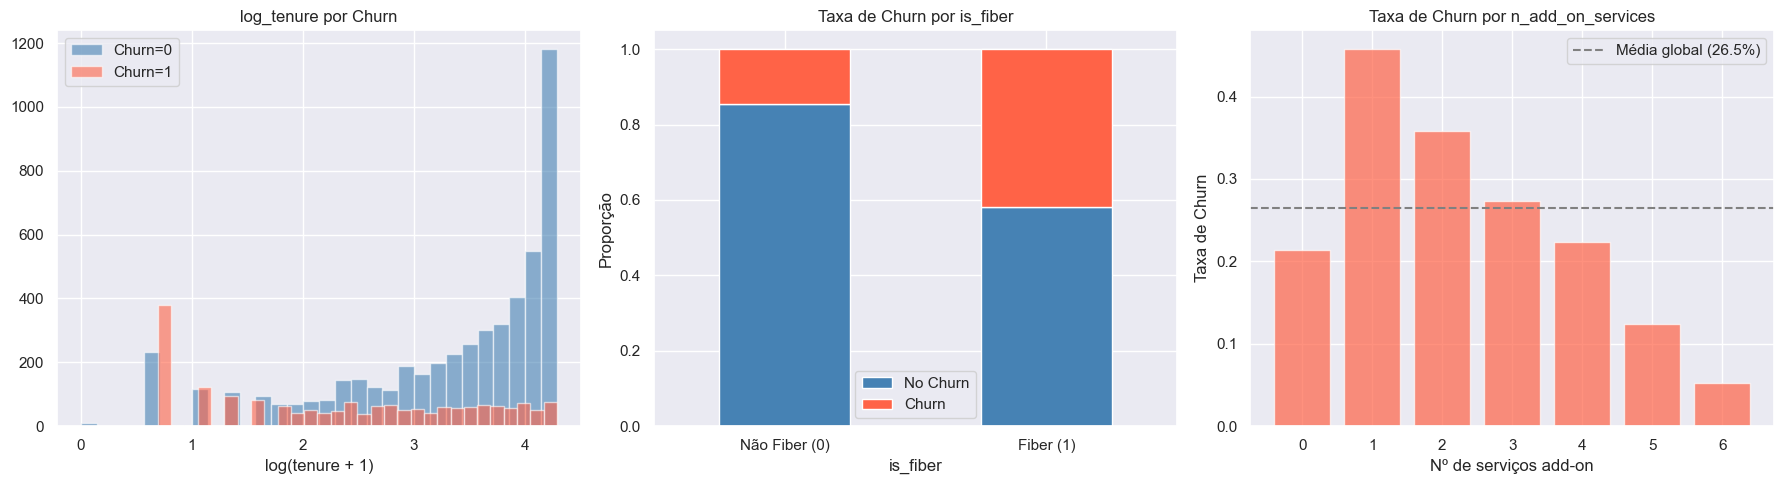

In [6]:
X_eng_plot = X_eng.copy()
X_eng_plot['Churn'] = y.values

fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# log_tenure
for label, color in [(0, 'steelblue'), (1, 'tomato')]:
    subset = X_eng_plot[X_eng_plot['Churn'] == label]
    axes[0].hist(subset['log_tenure'], bins=30, alpha=0.6, label=f'Churn={label}', color=color)
axes[0].set_title('log_tenure por Churn')
axes[0].set_xlabel('log(tenure + 1)')
axes[0].legend()

# is_fiber
ct = X_eng_plot.groupby(['is_fiber', 'Churn']).size().unstack(fill_value=0)
ct_pct = ct.div(ct.sum(axis=1), axis=0)
ct_pct.plot(kind='bar', stacked=True, ax=axes[1], color=['steelblue', 'tomato'])
axes[1].set_title('Taxa de Churn por is_fiber')
axes[1].set_xlabel('is_fiber')
axes[1].set_ylabel('Proporção')
axes[1].set_xticklabels(['Não Fiber (0)', 'Fiber (1)'], rotation=0)
axes[1].legend(['No Churn', 'Churn'])

# n_add_on_services
churn_by_addon = X_eng_plot.groupby('n_add_on_services')['Churn'].mean()
axes[2].bar(churn_by_addon.index, churn_by_addon.values, color='tomato', alpha=0.7)
axes[2].axhline(y=y.mean(), color='gray', linestyle='--', label=f'Média global ({y.mean():.1%})')
axes[2].set_title('Taxa de Churn por n_add_on_services')
axes[2].set_xlabel('Nº de serviços add-on')
axes[2].set_ylabel('Taxa de Churn')
axes[2].legend()

plt.tight_layout()
plt.show()

### 3.3 Correlação das features numéricas (pós-engineering)

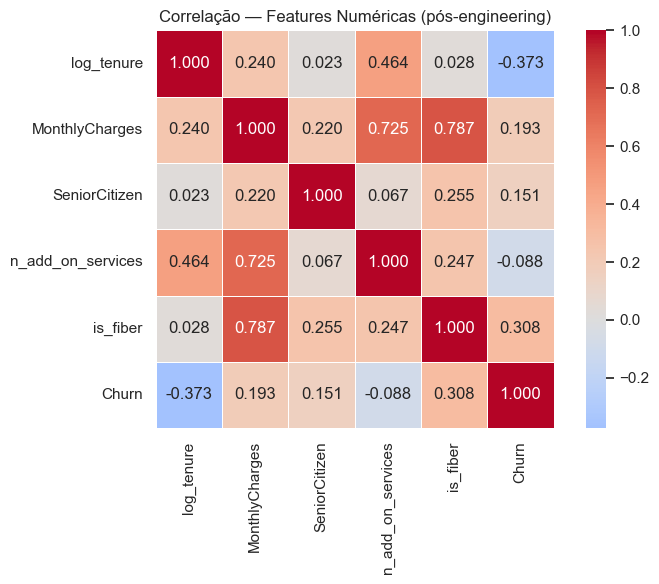


Correlação com Churn:
  log_tenure               : -0.3733
  MonthlyCharges           : +0.1934
  SeniorCitizen            : +0.1509
  n_add_on_services        : -0.0877
  is_fiber                 : +0.3080


In [7]:
corr_cols = ['log_tenure', 'MonthlyCharges', 'SeniorCitizen', 'n_add_on_services', 'is_fiber']
corr_df = X_eng_plot[corr_cols + ['Churn']].corr()

plt.figure(figsize=(8, 6))
sns.heatmap(corr_df, annot=True, fmt='.3f', cmap='coolwarm', center=0,
            square=True, linewidths=0.5)
plt.title('Correlação — Features Numéricas (pós-engineering)')
plt.tight_layout()
plt.show()

print('\nCorrelação com Churn:')
for col in corr_cols:
    c = X_eng_plot[col].corr(X_eng_plot['Churn'])
    print(f'  {col:25s}: {c:+.4f}')

## 4. Pipeline Completo (engineering + encoding + scaling)

Testando o pipeline de ponta a ponta com train/test split.

In [8]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=RANDOM_SEED, stratify=y
)
print(f'Train: {X_train.shape} | Test: {X_test.shape}')
print(f'Train target: {y_train.value_counts().to_dict()}')
print(f'Test target:  {y_test.value_counts().to_dict()}')

Train: (5634, 19) | Test: (1409, 19)
Train target: {0: 4139, 1: 1495}
Test target:  {0: 1035, 1: 374}


In [9]:
pipeline = build_pipeline()

X_train_transformed = fit_transform(pipeline, X_train)
X_test_transformed = transform(pipeline, X_test)

print(f'X_train transformado: {X_train_transformed.shape}')
print(f'X_test transformado:  {X_test_transformed.shape}')
print(f'NaN no train: {np.isnan(X_train_transformed).sum()}')
print(f'NaN no test:  {np.isnan(X_test_transformed).sum()}')

2026-04-23 14:27:00 [info     ] features.engineered            dropped=['gender', 'PhoneService', 'MultipleLines', 'TotalCharges', 'StreamingTV', 'StreamingMovies'] new_cols=['log_tenure', 'is_fiber', 'n_add_on_services'] shape=(5634, 15)


2026-04-23 14:27:00 [info     ] pipeline.fit_transform         output_shape=(5634, 30)


2026-04-23 14:27:00 [info     ] features.engineered            dropped=['gender', 'PhoneService', 'MultipleLines', 'TotalCharges', 'StreamingTV', 'StreamingMovies'] new_cols=['log_tenure', 'is_fiber', 'n_add_on_services'] shape=(1409, 15)


X_train transformado: (5634, 30)
X_test transformado:  (1409, 30)
NaN no train: 0
NaN no test:  0


### 4.1 Nomes das features finais (pós-pipeline)

In [10]:
preprocessor = pipeline.named_steps['preprocessor']
feature_names = preprocessor.get_feature_names_out()

print(f'Total de features no output: {len(feature_names)}')
print()
for i, name in enumerate(feature_names, 1):
    print(f'  {i:2d}. {name}')

Total de features no output: 30

   1. num__log_tenure
   2. num__MonthlyCharges
   3. num__SeniorCitizen
   4. num__n_add_on_services
   5. bin__Partner
   6. bin__Dependents
   7. bin__PaperlessBilling
   8. bin__is_fiber
   9. cat__InternetService_DSL
  10. cat__InternetService_Fiber optic
  11. cat__InternetService_No
  12. cat__OnlineSecurity_No
  13. cat__OnlineSecurity_No internet service
  14. cat__OnlineSecurity_Yes
  15. cat__OnlineBackup_No
  16. cat__OnlineBackup_No internet service
  17. cat__OnlineBackup_Yes
  18. cat__DeviceProtection_No
  19. cat__DeviceProtection_No internet service
  20. cat__DeviceProtection_Yes
  21. cat__TechSupport_No
  22. cat__TechSupport_No internet service
  23. cat__TechSupport_Yes
  24. cat__Contract_Month-to-month
  25. cat__Contract_One year
  26. cat__Contract_Two year
  27. cat__PaymentMethod_Bank transfer (automatic)
  28. cat__PaymentMethod_Credit card (automatic)
  29. cat__PaymentMethod_Electronic check
  30. cat__PaymentMethod_Maile

### 4.2 Distribuição do array transformado

In [11]:
df_transformed = pd.DataFrame(X_train_transformed, columns=feature_names)

print('Estatísticas descritivas (primeiras 8 features):')
df_transformed.iloc[:, :8].describe().round(3)

Estatísticas descritivas (primeiras 8 features):


,num__log_tenure,num__MonthlyCharges,num__SeniorCitizen,num__n_add_on_services,bin__Partner,bin__Dependents,bin__PaperlessBilling,bin__is_fiber
count,5634.000,5634.000,5634.000,5634.000,5634.000,5634.000,5634.000,5634.000
mean,0.000,-0.000,0.000,0.000,0.484,0.298,0.591,0.441
std,1.000,1.000,1.000,1.000,0.500,0.457,0.492,0.497
min,-2.643,-1.544,-0.442,-1.110,0.000,0.000,0.000,0.000
25%,-0.643,-0.971,-0.442,-1.110,0.000,0.000,0.000,0.000
50%,0.311,0.185,-0.442,-0.031,0.000,0.000,1.000,0.000
75%,0.853,0.832,-0.442,0.508,1.000,1.000,1.000,1.000
max,1.083,1.786,2.264,2.126,1.000,1.000,1.000,1.000


## 5. Sanity Checks

In [12]:
checks = []

# 1. Sem NaN
no_nan = not np.isnan(X_train_transformed).any() and not np.isnan(X_test_transformed).any()
checks.append(('Sem NaN no output', no_nan))

# 2. Shape consistente
shape_ok = X_train_transformed.shape[1] == X_test_transformed.shape[1]
checks.append(('Shape train == test (colunas)', shape_ok))

# 3. Determinístico
p2 = build_pipeline()
r2 = fit_transform(p2, X_train)
deterministic = np.allclose(X_train_transformed, r2)
checks.append(('Pipeline determinístico', deterministic))

# 4. Features removidas não estão presentes
eng_test = engineer_features(X_test)
all_dropped = all(c not in eng_test.columns for c in _DROP_COLS)
checks.append(('Features removidas ausentes', all_dropped))

# 5. log_tenure >= 0
log_ok = (engineer_features(X)['log_tenure'] >= 0).all()
checks.append(('log_tenure >= 0', log_ok))

# 6. n_add_on_services em [0, 6]
addon = engineer_features(X)['n_add_on_services']
addon_ok = (addon >= 0).all() and (addon <= 6).all()
checks.append(('n_add_on_services em [0, 6]', addon_ok))

print('=== SANITY CHECKS ===')
all_passed = True
for name, passed in checks:
    status = 'PASS' if passed else 'FAIL'
    if not passed:
        all_passed = False
    print(f'  [{status}] {name}')

print()
if all_passed:
    print('Todos os checks passaram!')
else:
    print('ATENÇÃO: alguns checks falharam.')

2026-04-23 14:27:00 [info     ] features.engineered            dropped=['gender', 'PhoneService', 'MultipleLines', 'TotalCharges', 'StreamingTV', 'StreamingMovies'] new_cols=['log_tenure', 'is_fiber', 'n_add_on_services'] shape=(5634, 15)


2026-04-23 14:27:00 [info     ] pipeline.fit_transform         output_shape=(5634, 30)


2026-04-23 14:27:00 [info     ] features.engineered            dropped=['gender', 'PhoneService', 'MultipleLines', 'TotalCharges', 'StreamingTV', 'StreamingMovies'] new_cols=['log_tenure', 'is_fiber', 'n_add_on_services'] shape=(1409, 15)


2026-04-23 14:27:00 [info     ] features.engineered            dropped=['gender', 'PhoneService', 'MultipleLines', 'TotalCharges', 'StreamingTV', 'StreamingMovies'] new_cols=['log_tenure', 'is_fiber', 'n_add_on_services'] shape=(7043, 15)


2026-04-23 14:27:00 [info     ] features.engineered            dropped=['gender', 'PhoneService', 'MultipleLines', 'TotalCharges', 'StreamingTV', 'StreamingMovies'] new_cols=['log_tenure', 'is_fiber', 'n_add_on_services'] shape=(7043, 15)


=== SANITY CHECKS ===
  [PASS] Sem NaN no output
  [PASS] Shape train == test (colunas)
  [PASS] Pipeline determinístico
  [PASS] Features removidas ausentes
  [PASS] log_tenure >= 0
  [PASS] n_add_on_services em [0, 6]

Todos os checks passaram!


## 6. Resumo

| Métrica | Antes | Depois |
|---------|------:|-------:|
| Features de entrada | 19 | 13 |
| Colunas pós-pipeline | 40 | ~30 |
| Features criadas | — | 3 (log_tenure, is_fiber, n_add_on_services) |
| Features removidas | — | 6 (gender, PhoneService, MultipleLines, TotalCharges, StreamingTV, StreamingMovies) |
| NaN no output | 0 | 0 |